#### Cyclical Features

Features in typical ML datasets include:

 - Numerical features like age, income, transaction amt, etc.
 - Categorical features like t-shirt size, income groups, age groups, etc.

Unlike other features that progress continuously (or have no inherent order), cyclical features exhibit periodic behavior.

For instance, here are some common examples of cyclical features.

- hour of a day (0 -> 1 -> .. -> 23 -> repeats from 0)
- day of the week (M -> T -> .... -> S -> S -> repeats from M)
- month of the year

The standard linear representation does not fulfill these properties because:

- The value “23” is far from “0”
- And the distance property isn’t satisfied either.

> One of the most common techniques to encode such a feature is using trigonometric functions, specifically, sine and cosine.

For a feature x with period T (e.g., 24 for hours, 7 for days):

- Normalize to [0, 1): x_norm = x / T
- Map to angle: theta = 2 * π * x_norm
- Encode as 2D point: (sin(theta), cos(theta))

They map the linear scale to a circle (which is a 2D), preserving distances. Sine handles the "up-down" cycle, cosine the "left-right," allowing models to learn smooth periodic functions.

They are helpful because both are periodic, bounded, and defined for all real values.

A cycle (like hours in a day) is a circle. To encode it numerically, we need to map the linear value (e.g., hour 0 to 23) to points on a circle. But models work in flat, Euclidean space—not circles.

- Sine alone: Maps to a 1D line (up-down), but loses the full circle info. For example, sin(0°) = 0, sin(180°) = 0—same value for opposite points!
- Cosine alone: Same issue—cos(90°) = 0, cos(270°) = 0.
- Sine and cosine are 90° out of phase, making them orthogonal (independent).
- Both together: (sin, cos) gives a unique 2D point for each angle, covering the entire circle without ambiguity.

For instance, when representing the linear ‘hour of a day’ feature as a cyclical feature, the central angle (2π) will denote 24 hours.

##### Why this encoding helps
 - Preserves distances: Euclidean distance in the 2D space matches the cyclic distance.
 - Handles wrap-around: No discontinuity at cycle boundaries.
 - Model-friendly: Neural networks can learn smooth functions over the circle.
 - Reduces bias: Prevents models from treating high/low values as extremes.

Without it, models might learn spurious patterns, like "late hours are bad" when it's just proximity to midnight.

##### Practical use in production

1. Time-series forecasting: Encoding hour/day/month for demand prediction, traffic, or energy usage.
2. Recommendation systems: User activity patterns by time of day/week.
3. Fraud detection: Transaction timing anomalies (e.g., unusual hours).
4. Geospatial: Wind directions, compass bearings in weather/climate models.
5. Retail/e-commerce: Seasonal sales cycles, promotional timing.
6. IoT/Sensors: Periodic sensor readings (e.g., daily temperature cycles).

Where cyclical encoding is applied
1. Always for time features in ML pipelines.
2. In feature engineering pipelines before model training.
3. Often combined with other time features (e.g., holidays, trends).

In [1]:
import numpy as np
import pandas as pd

# Create sample data
hours = [0, 6, 12, 18, 23, 24]  # 24 wraps to 0
df = pd.DataFrame({'hour': hours})

# Encode cyclically
df['sin_hour'] = np.sin(df['hour'] * 2 * np.pi / 24)
df['cos_hour'] = np.cos(df['hour'] * 2 * np.pi / 24)

print(df)

   hour      sin_hour      cos_hour
0     0  0.000000e+00  1.000000e+00
1     6  1.000000e+00  6.123234e-17
2    12  1.224647e-16 -1.000000e+00
3    18 -1.000000e+00 -1.836970e-16
4    23 -2.588190e-01  9.659258e-01
5    24 -2.449294e-16  1.000000e+00


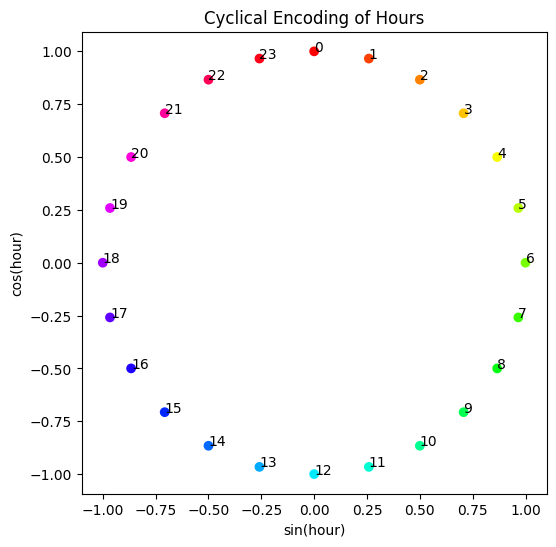

In [2]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)
sin_hours = np.sin(hours * 2 * np.pi / 24)
cos_hours = np.cos(hours * 2 * np.pi / 24)

plt.figure(figsize=(6,6))
plt.scatter(sin_hours, cos_hours, c=hours, cmap='hsv')
plt.xlabel('sin(hour)')
plt.ylabel('cos(hour)')
plt.title('Cyclical Encoding of Hours')
plt.axis('equal')
for i, h in enumerate(hours):
    plt.annotate(str(h), (sin_hours[i], cos_hours[i]))
plt.show()